# Gradient TD methods

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

In [2]:
class BairdsEnv(gym.Env):
    def __init__(self):
        super(BairdsEnv, self).__init__()
        self.state = None
        self.observation_space = gym.spaces.Dict({
            "state":gym.spaces.Box(low=0, high=6, shape=(1,), dtype=np.int32)
        })

        self.action_space = gym.spaces.Discrete(n=2)

    def reset(self):
        self.state = int(self.observation_space.sample()['state'][0])
        return self.state

    def step(self, action):
        if action == 0:
            # the action is a "solid" action
            self.state = 6
        elif action == 1:
            # the action is a "dashed" action
            self.state = np.random.choice(6)

        return self.state, 0.0

In [49]:
def target_policy(state):
    return 0

def behaviour_policy(state):
    return int(np.random.choice([0, 1], p=[1/7, 6/7]))

def importance_sampling_ratio(state, action):
    if action == 0:
        target_p = 1.0
        behaviour_p = 1/7
    else:
        target_p = 0.0
        behaviour_p = 6/7

    return target_p / behaviour_p

def get_mu():
    return np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6, 0])

def transition_probability(next_state, state, action):
    if action == 0 and next_state < 6:
        return 0.0
    elif action == 0 and next_state == 6:
        return 1.0

    if action == 1 and next_state == 6:
        return 0.0
    elif action == 1 and next_state < 6:
        return 1/6
    return 0.0

def feature_vector(state:int):
    if state < 6:
        vector = np.zeros(8, dtype=np.float32)
        vector[state] = 2
        vector[7] = 1
        return vector

    vector = np.zeros(8, dtype=np.float32)
    vector[state] = 1
    vector[7] = 2
    return vector

def plot(history:list[np.ndarray], ax, x_label, title):
    history = np.concat([h[None, ...] for h in history], axis=0)
    for i in range(8):
        ax.plot(history[:, i])
    
    ax.set_xticks([0, 1000]);
    ax.set_yticks([-2.4, 0, 2, 5, 10]);
    ax.spines.pop('right')
    ax.spines.pop('top')
    ax.set_title(title, fontdict={'fontweight':400, 'fontsize':16})
    ax.set_xlabel(x_label)
    ax.set_ylim([-3, 10])

In [50]:
def compute_ve(w):
    ve = 0
    mu = get_mu()
    for state in range(7):
        x = feature_vector(state)
        ve += mu[state] * (w@x) ** 2
    return ve

In [51]:
def compute_projection_matrix():
    # X(X^TDX)^-1 X^TD
    X = np.stack([feature_vector(x) for x in range(7)])
    mu = get_mu()
    D = np.diag(mu)
    return X @ np.linalg.pinv(X.T@D@X) @ X.T @ D

def compute_be(w, gamma):
    be = np.zeros(7, dtype=np.float32)
    for state in range(7):
        x_state = feature_vector(state)
        v_state = w.T @ x_state
        for a in range(2):
            action_prob = 1/7 if a == 0 else 6/7
            for next_state in range(7):
                trans_prob = transition_probability(next_state, state, a)
                x_next_state = feature_vector(next_state)
                v_next_state = w.T@x_next_state
                be[state] += trans_prob * action_prob * (gamma * v_next_state)
        be[state] = be[state] - v_state
    return be

def compute_pbe(w, gamma):
    X = np.stack([feature_vector(x) for x in range(7)])
    mu = get_mu()
    D = np.diag(mu)
    XDX_inv = np.linalg.pinv(X.T@D@X)
    delta_w = compute_be(w, gamma)
    return (X.T @ D @ delta_w).T @ XDX_inv @ (X.T @ D @ delta_w)

## GTD2

In [56]:
def gtd2(
    env:BairdsEnv,
    w:np.ndarray,
    steps:int,
    alpha:float=0.005,
    beta:float=0.05,
    gamma:float=0.99
):
    w = w.copy()
    d = w.shape[0]
    v = np.zeros(d, dtype=np.float32)
    state = env.reset()
    weight_history = []
    pbe_history = []
    ve_history = []

    for step in range(steps):
        action = behaviour_policy(state)
        next_state, reward = env.step(action)

        x_state = feature_vector(state)
        x_next_state = feature_vector(next_state)
        rho_t = importance_sampling_ratio(state, action)
        td_error = reward + gamma * w.T@x_next_state - w.T@x_state
        v = v + rho_t * beta * (td_error - v.T@x_state) * x_state

        temp = x_state.T@v
        w = w + alpha * rho_t * (x_state - gamma * x_next_state) * temp

        state = next_state
        weight_history.append(w)
        pbe_history.append(np.sqrt(compute_pbe(w, gamma=gamma)))
        ve_history.append(np.sqrt(compute_ve(w)))

    return w, weight_history, pbe_history, ve_history

## TDC

In [57]:
def tdc(
    env:BairdsEnv,
    w:np.ndarray,
    steps:int,
    alpha:float=0.005,
    beta:float=0.05,
    gamma:float=0.99
):
    w = w.copy()
    d = w.shape[0]
    v = np.zeros(d, dtype=np.float32)
    state = env.reset()
    weight_history = []
    pbe_history = []
    ve_history = []

    for step in range(steps):
        action = behaviour_policy(state)
        next_state, reward = env.step(action)

        x_state = feature_vector(state)
        x_next_state = feature_vector(next_state)
        rho_t = importance_sampling_ratio(state, action)
        td_error = reward + gamma * w.T@x_next_state - w.T@x_state
        v = v + rho_t * beta * (td_error - v.T@x_state) * x_state

        temp = x_state.T@v
        w = w + alpha * rho_t * (td_error * x_state - gamma * x_next_state * temp)

        state = next_state
        weight_history.append(w)
        pbe_history.append(np.sqrt(compute_pbe(w, gamma=gamma)))
        ve_history.append(np.sqrt(compute_ve(w)))

    return w, weight_history, pbe_history, ve_history

In [79]:
w = np.array([1, 1, 1, 1, 1, 1, 10, 1])
w_gtd2, history_gtd2, _, _ = gtd2(
    env=BairdsEnv(),
    w=w,
    steps=1000
)

w_tdc, history_tdc, pbe_history, ve_history = tdc(
    env=BairdsEnv(),
    w=w,
    steps=1000
)

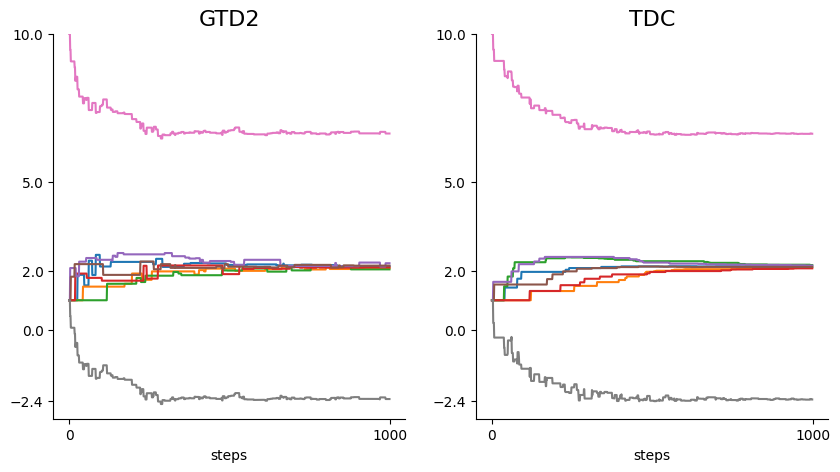

In [80]:
fig = plt.figure(figsize=(10, 5))
ax = plt.subplot(121)
plot(history_gtd2, ax, x_label='steps', title='GTD2')

ax = plt.subplot(122)
plot(history_tdc, ax, x_label='steps', title='TDC')

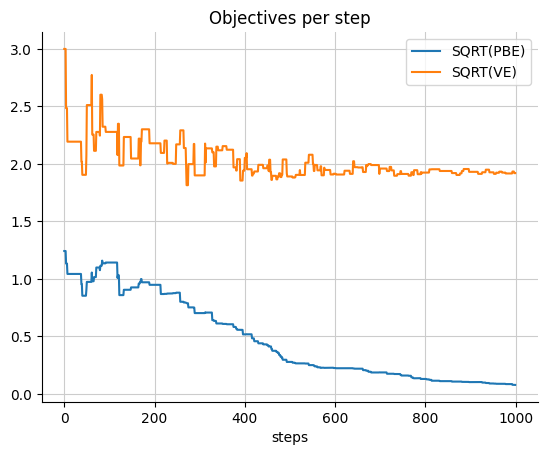

In [81]:
fig = plt.figure()
ax = plt.subplot(111)
ax.plot(pbe_history, label='SQRT(PBE)')
ax.plot(ve_history, label='SQRT(VE)')
ax.grid(c='#ccc')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('steps')
ax.set_title('Objectives per step')
ax.legend();

## Expected TDC

In [103]:
def expected_tdc(
    w:np.ndarray,
    sweeps:int,
    alpha:float=0.005,
    beta:float=0.05,
    gamma:float=0.99
):
    w = w.copy()
    d = w.shape[0]
    v = np.zeros(d, dtype=np.float32)
    weight_history = []
    pbe_history = []
    ve_history = []

    mu = get_mu()

    for sweep in range(sweeps):
        v_expectation = np.zeros(d)
        w_expectation = np.zeros(d)
        for state in range(7):
            for action in range(2):
                for next_state in range(7):
                    rho_t = importance_sampling_ratio(state, action)
                    x_state = feature_vector(state)
                    x_next_state = feature_vector(next_state)
                    trans_prob = transition_probability(next_state, state, action)
                    action_prob = 1/7 if action == 0 else 6/7
                    td_error = gamma * w.T@x_next_state - w.T@x_state
                    v_expectation += rho_t * mu[state] * trans_prob * action_prob * (td_error - v.T@x_state) * x_state
            
                    temp = x_state.T@v
                    w_expectation += rho_t * mu[state] * trans_prob * action_prob * (td_error * x_state - gamma * x_next_state * temp)

        w = w + alpha * w_expectation
        v = v + beta * v_expectation
        weight_history.append(w)
        pbe_history.append(np.sqrt(compute_pbe(w, gamma=gamma)))
        ve_history.append(np.sqrt(compute_ve(w)))

    return w, weight_history, pbe_history, ve_history

In [104]:
w = np.array([1, 1, 1, 1, 1, 1, 10, 1])

w_tdc, history_tdc, pbe_history, ve_history = expected_tdc(
    w=w,
    sweeps=1000
)

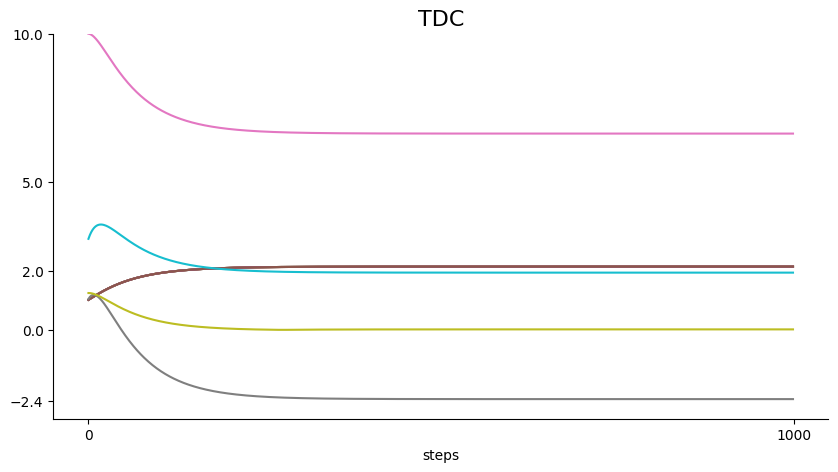

In [107]:
fig = plt.figure(figsize=(10, 5))
ax = plt.subplot(111)
plot(history_tdc, ax, x_label='steps', title='TDC')
ax.plot(pbe_history, label='SQRT(PBE)')
ax.plot(ve_history, label="SQER(VE)")